# Preprocessing Demo: Cleaning a Broken Dataset, Step by Step

This notebook is a **worked example**, not a template -- every cell is already filled in so you can watch the full cleaning process happen on a real (deliberately broken) dataset before you try it yourself.

**The dataset:** `data/broken_dataset_demo.csv` -- a student performance dataset (`passed`: did the student pass, yes/no). It looks plausible at a glance, but it has all six problems from Part II, slide 26 hiding inside it:

| Problem | Where it's hiding here |
|---|---|
| Missing values | `attendance_pct` (a little) and `prev_grade` (a lot) |
| Duplicate records | A handful of exact repeated rows |
| Outliers | A few students with impossible `hours_studied` values |
| Wrong data types | `hours_studied` sometimes stored as text like `"7.2h"` |
| Class imbalance | Far more students failed than passed |
| Data leakage | `final_exam_result` literally encodes the answer |

We'll find every one of these using the notebook 02 inspection habits, then fix them one at a time. **After this notebook, you'll do the same thing yourself** on a different broken dataset in `05_preprocessing_practice.ipynb`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (7, 4.5)

print("Environment ready.")

Environment ready.


## Step 1: Load and Take a First Look

Same habit every time (Part II, slide 24): load it, then look at it before assuming anything.

In [8]:
df = pd.read_csv("data/broken_dataset_demo.csv")
print(f"Loaded {df.shape[0]} rows x {df.shape[1]} columns")
df.head(10)

Loaded 256 rows x 7 columns


,student_id,hours_studied,attendance_pct,prev_grade,study_group,passed,final_exam_result
0,54,9.3,49.6,NaN,A,0,fail
1,206,5.7,NaN,NaN,A,0,fail
2,36,5.6,39.5,NaN,A,0,fail
3,11,9.7,43.3,NaN,A,1,pass
4,189,2.2,34.5,68.3,A,0,fail
5,31,2.9,83.8,71.7,A,0,fail
6,161,9.9,NaN,NaN,C,0,fail
7,127,3.7,94.5,NaN,A,0,fail
8,241,6.8,NaN,NaN,C,0,fail
9,14,0.4,47.4,NaN,A,0,fail


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   student_id         256 non-null    int64  
 1   hours_studied      256 non-null    str    
 2   attendance_pct     236 non-null    float64
 3   prev_grade         115 non-null    float64
 4   study_group        256 non-null    str    
 5   passed             256 non-null    int64  
 6   final_exam_result  256 non-null    str    
dtypes: float64(2), int64(2), str(3)
memory usage: 14.1 KB


**First red flag already:** `hours_studied` should be a number, but `.info()` shows it as `object` (text). We were told this column contains "hours studied" -- a number of hours -- so this is a mismatch between what we expected and what we're seeing (the exact question Part II slide 24 tells us to ask). We'll come back to this in Step 5.

## Step 2: Missing Values

`df.isna().sum()` tells us *how much* is missing per column -- and the percentage decides what to do about it (Part II, slide 26): drop the column if most of it is missing, impute if it's a smaller gap.

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).query("missing_count > 0")

,missing_count,missing_pct
attendance_pct,20,7.8
prev_grade,141,55.1


**Two different situations, two different fixes:**

- `attendance_pct` is missing a small amount (~8%). Small enough to safely impute -- we'll fill it with the median, which is robust to any outliers still sitting in the data.
- `prev_grade` is missing more than half its values (~55%). Past that point, imputing would mean *inventing* the majority of a column's values, which teaches the model a pattern that's mostly guesswork. The safer move is to **drop the column entirely**.

This is exactly the "drop the rows, drop the column, or impute" decision from Part II slide 26 -- the percentage missing is what tells you which of the three to pick.

In [6]:
# Drop prev_grade entirely -- over half of it is missing
df = df.drop(columns=["prev_grade"])

# Impute attendance_pct with the median -- only a small gap, safe to fill
df["attendance_pct"] = df["attendance_pct"].fillna(df["attendance_pct"].median())

print("Remaining missing values:")
print(df.isna().sum())

Remaining missing values:
student_id           0
hours_studied        0
attendance_pct       0
study_group          0
passed               0
final_exam_result    0
dtype: int64


## Step 3: Duplicate Records

Exact duplicate rows inflate whatever statistics we compute next, and if left in place until after a train/test split, the *same* row can end up in both splits -- silently leaking information from training into "unseen" test data. So we handle this now, before anything else touches the rows.

In [6]:
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {n_duplicates}")

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Rows: {before} -> {len(df)}")

Duplicate rows found: 5
Rows: 256 -> 251


## Step 4: Wrong Data Types

Back to the red flag from Step 1: `hours_studied` should be numeric but is stored as text. Let's see why.

In [7]:
# Look at a sample of the raw values -- what's actually in this column?
df["hours_studied"].sample(10, random_state=1)

67      7.3
250     5.2
230     3.2
161     4.3
91      5.9
224     3.5
58      2.4
234     1.6
180    10.2
4       2.2
Name: hours_studied, dtype: str

Some values are plain numbers, others have a trailing `"h"` (like `"7.2h"`) -- probably someone exported this from a system that appended units inconsistently. Either way, pandas can't do math on text, so we need to strip the `"h"` and convert to a float.

In [8]:
df["hours_studied"] = (
    df["hours_studied"].astype(str).str.replace("h", "", regex=False).astype(float)
)

print(df["hours_studied"].dtype)
df["hours_studied"].describe()

float64


count    251.000000
mean      21.668183
std      111.164957
min        0.300000
25%        3.250000
50%        5.800000
75%        9.400000
max      910.969215
Name: hours_studied, dtype: float64

Now it's numeric -- and look at that `max`. Nobody studies for hundreds of hours in a single stretch. That's not a legitimate extreme value, it's almost certainly a data-entry error. We'll deal with it properly in a moment.

**One more thing worth checking first:** fixing a dtype can sometimes *reveal* duplicates that were hiding behind inconsistent formatting -- e.g. `"7.2h"` and `"7.2"` look different to `.duplicated()` as text, but are the same value once converted to a number. Let's re-check now that the column is clean.

In [9]:
n_new_duplicates = df.duplicated().sum()
print(f"Duplicate rows now visible: {n_new_duplicates}")

if n_new_duplicates > 0:
    before = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Rows: {before} -> {len(df)}")
    print("\nLesson: a dtype problem can mask a duplicate problem. Always worth re-checking")
    print("for duplicates after fixing a column's type, not just once at the start.")

Duplicate rows now visible: 1
Rows: 251 -> 250

Lesson: a dtype problem can mask a duplicate problem. Always worth re-checking
for duplicates after fixing a column's type, not just once at the start.


## Step 5: Outliers

A box plot makes the problem visible; the IQR rule (same idea as the box plot's whiskers) turns it into an exact list of rows to look at.

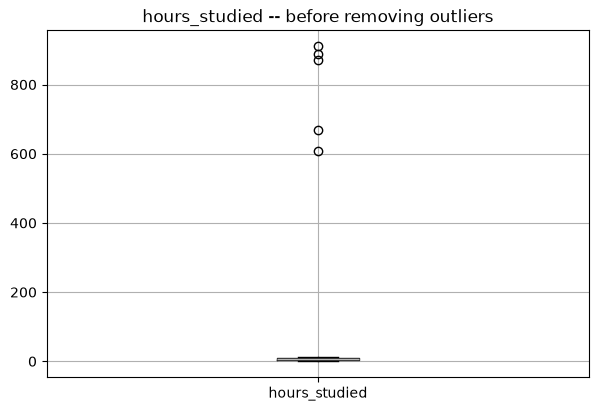

In [10]:
fig, ax = plt.subplots()
df.boxplot(column="hours_studied", ax=ax)
ax.set_title("hours_studied -- before removing outliers")
plt.show()

In [11]:
q1, q3 = df["hours_studied"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_mask = (df["hours_studied"] < lower) | (df["hours_studied"] > upper)
print(f"IQR bounds: [{lower:.1f}, {upper:.1f}]")
print(f"Outlier rows: {outlier_mask.sum()}")
df.loc[outlier_mask, ["student_id", "hours_studied"]]

IQR bounds: [-6.0, 18.7]
Outlier rows: 5


,student_id,hours_studied
12,185,606.623798
53,100,910.969215
96,234,871.619793
129,217,888.152202
175,61,669.948807


Values in the hundreds confirm these are data-entry errors, not genuine extreme study habits (a genuine outlier here would look like 15-20 hours, not 400+). We'll drop these rows rather than try to guess the "real" value -- inventing a number would be worse than losing five rows out of 250.

Rows: 250 -> 245


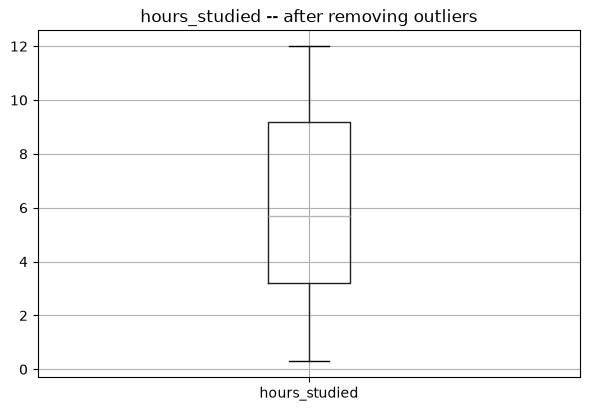

In [12]:
before = len(df)
df = df.loc[~outlier_mask].reset_index(drop=True)
print(f"Rows: {before} -> {len(df)}")

fig, ax = plt.subplots()
df.boxplot(column="hours_studied", ax=ax)
ax.set_title("hours_studied -- after removing outliers")
plt.show()

## Step 6: Data Leakage

This is the most dangerous problem on the list because it's invisible in a model's score -- it makes accuracy look *better*, not worse, until the model reaches production and the leaked column simply isn't available anymore (Part II, slide 26).

Let's look at the columns we haven't touched yet.

In [13]:
df[["passed", "final_exam_result"]].head(10)

,passed,final_exam_result
0,0,fail
1,0,fail
2,0,fail
3,1,pass
4,0,fail
5,0,fail
6,0,fail
7,0,fail
8,0,fail
9,0,fail


`final_exam_result` is just `passed` spelled out as `"pass"`/`"fail"` -- it's a restatement of the target, not a feature. Ask the leakage question from notebook 03: *"would I actually have this value at prediction time?"* No -- if you're predicting whether a student will pass, you can't also already know their final exam result; that's the thing you're trying to predict in the first place. If we left this column in, a model would learn to just read it off directly and score ~100% -- and then fail completely in the real world, where this column wouldn't exist yet.

We drop it.

In [14]:
df = df.drop(columns=["final_exam_result"])
print("Remaining columns:", list(df.columns))

Remaining columns: ['student_id', 'hours_studied', 'attendance_pct', 'study_group', 'passed']


## Step 7: Class Imbalance

Unlike the previous five problems, this one isn't something we "fix" by changing the data -- it's something we need to *know about* so we evaluate the eventual model correctly (Part II, slide 26).

passed
0    0.788
1    0.212
Name: proportion, dtype: float64


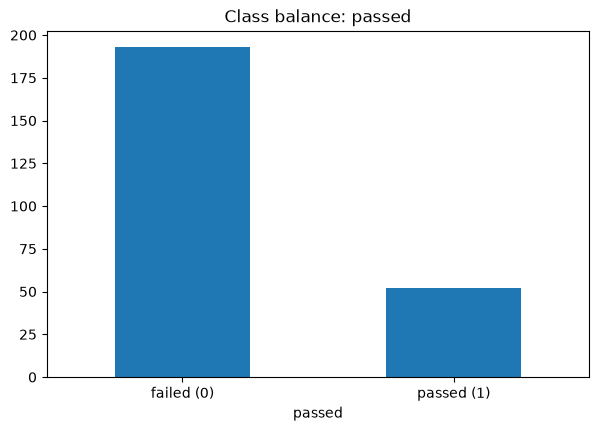

In [15]:
class_counts = df["passed"].value_counts(normalize=True)
print(class_counts.round(3))

fig, ax = plt.subplots()
df["passed"].value_counts().plot(kind="bar", ax=ax)
ax.set_xticklabels(["failed (0)", "passed (1)"], rotation=0)
ax.set_title("Class balance: passed")
plt.show()

About 78% failed, 22% passed. Nothing to clean here -- but it's a fact we now carry forward: **accuracy alone would be misleading** on this dataset, because a model that always predicts "failed" would score ~78% while catching zero actual passes. When we get to modelling (notebook 03), this is why we'll watch precision/recall/F1 instead of accuracy, and why `train_test_split(..., stratify=y)` matters -- it keeps this same ~78/22 split intact in both the training and test sets.

## Step 8: Feature Engineering

All six problems are handled. One thing left before this data is model-ready: `study_group` is a category (`"A"`, `"B"`, `"C"`), and models need numbers. `pd.get_dummies` turns it into 0/1 columns, one per category (minus one, to avoid redundancy).

In [16]:
df = pd.get_dummies(df, columns=["study_group"], drop_first=True)
df.head()

,student_id,hours_studied,attendance_pct,passed,study_group_B,study_group_C
0,54,9.3,49.6,0,False,False
1,206,5.7,63.1,0,False,False
2,36,5.6,39.5,0,False,False
3,11,9.7,43.3,1,False,False
4,189,2.2,34.5,0,False,False


## Final Check: Did We Actually Fix Everything?

Re-run the same diagnostics from Step 1-7 one more time. This is worth doing every time -- "I fixed it" should always be followed by "let me verify that."

In [17]:
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"hours_studied dtype: {df['hours_studied'].dtype}  (should be numeric)")
print(f"hours_studied range: [{df['hours_studied'].min():.1f}, {df['hours_studied'].max():.1f}]  (should look plausible)")
print(f"Leakage column present: {'final_exam_result' in df.columns}  (should be False)")
print(f"\nFinal columns: {list(df.columns)}")
df.head()

Shape: (245, 6)
Missing values: 0
Duplicate rows: 0
hours_studied dtype: float64  (should be numeric)
hours_studied range: [0.3, 12.0]  (should look plausible)
Leakage column present: False  (should be False)

Final columns: ['student_id', 'hours_studied', 'attendance_pct', 'passed', 'study_group_B', 'study_group_C']


,student_id,hours_studied,attendance_pct,passed,study_group_B,study_group_C
0,54,9.3,49.6,0,False,False
1,206,5.7,63.1,0,False,False
2,36,5.6,39.5,0,False,False
3,11,9.7,43.3,1,False,False
4,189,2.2,34.5,0,False,False


## Summary

Here's everything we did, and why, in order:

| # | Problem found | How we found it | How we fixed it |
|---|---|---|---|
| 1 | Wrong dtype | `.info()` showed `hours_studied` as `object` | Stripped `"h"` suffix, cast to `float` |
| 2 | Missing values | `.isna().sum()` | Dropped `prev_grade` (55% missing); imputed `attendance_pct` with median (8% missing) |
| 3 | Duplicates | `.duplicated().sum()` | `.drop_duplicates()` -- twice: once at the start, once more after fixing the dtype |
| 4 | Outliers | Box plot + IQR rule, after fixing the dtype | Dropped 5 rows with impossible `hours_studied` values |
| 5 | Data leakage | Compared `final_exam_result` against `passed` directly | Dropped the column |
| 6 | Class imbalance | `.value_counts(normalize=True)` | Not "fixed" -- noted for later: use F1 not accuracy, stratify the split |
| 7 | Categorical feature | `study_group` was text | `pd.get_dummies` |

Notice the **order** mattered, twice over:
- We had to fix the dtype before we could check for outliers on that column -- IQR math doesn't work on text.
- Fixing that same dtype also *revealed* a duplicate that inconsistent formatting (`"7.2h"` vs `"7.2"`) had been hiding from the first duplicate check.

That's a real pattern, not a one-off: a dtype problem can mask other problems underneath it. It's worth re-running `.duplicated().sum()` after any dtype fix, not just once at the very start.

**Your turn:** open `05_preprocessing_practice.ipynb`. It has a boilerplate structure and a *different* broken dataset (`data/broken_dataset_practice.csv`) with the same six categories of problem, but different columns, different values, and no code filled in. Work through it the same way we just did here.